In [1]:
from results_utils import compute_results, plot_results_for_model, load_results_paths, compute_metric
import os
import pandas as pd

%load_ext autoreload
%autoreload 2

In [2]:
metrics = ["norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
bootstrap = 0
random_state = 42

if os.path.exists(f"results_{bootstrap}_{random_state}.csv"):
    df = pd.read_csv(f"results_{bootstrap}_{random_state}.csv", index_col=False)
else:
    df = compute_results(metrics, bootstrap, random_state)
    df.to_csv(f"results_{bootstrap}_{random_state}.csv", index=False)
df.loc[:,[c for c in df.columns if ":" not in c ]]

100%|██████████| 70/70 [08:18<00:00,  7.12s/it]


,dataset,size,num_samples,prompt,n_shots,model,base_method,cal_method,split,norm_error_rate,norm_cross_entropy,ece,cal_loss_bias,norm_min_calibration_bias
0,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,lora,no_calibration,test,0.172 ± 0.034,0.330 ± 0.045,0.032 ± 0.013,11.831 ± 8.132,0.288 ± 0.020
1,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar,test,0.326 ± 0.007,0.532 ± 0.012,0.032 ± 0.009,4.971 ± 2.176,0.506 ± 0.001
2,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,no_calibration,test,0.318 ± 0.000,0.683 ± 0.000,0.176 ± 0.001,25.944 ± 0.086,0.506 ± 0.001
3,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,bias_only,test,0.309 ± 0.007,0.682 ± 0.000,0.186 ± 0.004,25.868 ± 0.091,0.506 ± 0.001
4,sst2,256,512,basic_sst2_0-shot_litgpt,0,lm_tinyllama,no_adaptation,temp_scaling,test,0.318 ± 0.000,0.521 ± 0.005,0.031 ± 0.012,2.878 ± 0.837,0.506 ± 0.001
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,20newsgroups,256,5120,basic_20newsgroups_0-shot_litgpt,0,lm_tinyllama,lora,no_calibration,test,0.340 ± 0.011,0.349 ± 0.010,0.036 ± 0.010,8.474 ± 1.406,0.319 ± 0.012
66,20newsgroups,256,5120,basic_20newsgroups_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar,test,0.417 ± 0.001,0.440 ± 0.000,0.018 ± 0.002,0.284 ± 0.057,0.439 ± 0.000
67,20newsgroups,256,5120,basic_20newsgroups_0-shot_litgpt,0,lm_tinyllama,no_adaptation,no_calibration,test,0.605 ± 0.000,0.833 ± 0.000,0.243 ± 0.000,47.336 ± 0.000,0.439 ± 0.000
68,20newsgroups,256,5120,basic_20newsgroups_0-shot_litgpt,0,lm_tinyllama,no_adaptation,bias_only,test,0.417 ± 0.001,0.441 ± 0.000,0.022 ± 0.000,0.649 ± 0.013,0.439 ± 0.000


In [3]:
df_lora_cal = df.loc[
    (df["base_method"] == "lora_xval") & \
    ((df["cal_method"] == "no_calibration") | \
     (df["cal_method"] == "affine_scalar")  | \
     (df["cal_method"] == "temp_scaling") | \
     (df["cal_method"] == "bias_only")),
    ["dataset", "size", "base_method", "cal_method", "norm_error_rate", "norm_cross_entropy", "ece", "cal_loss_bias", "norm_min_calibration_bias"]
]
df_results = df.loc[(df["base_method"] != "lora_xval"), :]
df_lora_cal

,dataset,size,base_method,cal_method,norm_error_rate,norm_cross_entropy,ece,cal_loss_bias,norm_min_calibration_bias


In [4]:
df_results.loc[(df_results["dataset"] == "agnews") & (df_results["size"] == 8),[c for c in df_results.columns if ":" not in c ]]

,dataset,size,num_samples,prompt,n_shots,model,base_method,cal_method,split,norm_error_rate,norm_cross_entropy,ece,cal_loss_bias,norm_min_calibration_bias
10,agnews,8,32,basic_agnews_0-shot_litgpt,0,lm_tinyllama,lora,no_calibration,test,0.312 ± 0.086,0.426 ± 0.077,0.047 ± 0.020,23.426 ± 11.225,0.318 ± 0.009
11,agnews,8,32,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,affine_scalar,test,0.320 ± 0.030,0.451 ± 0.033,0.054 ± 0.025,13.280 ± 5.958,0.389 ± 0.000
12,agnews,8,32,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,no_calibration,test,0.410 ± 0.000,0.991 ± 0.001,0.125 ± 0.000,60.681 ± 0.002,0.389 ± 0.000
13,agnews,8,32,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,bias_only,test,0.315 ± 0.038,0.444 ± 0.034,0.055 ± 0.018,11.758 ± 6.221,0.389 ± 0.000
14,agnews,8,32,basic_agnews_0-shot_litgpt,0,lm_tinyllama,no_adaptation,temp_scaling,test,0.410 ± 0.000,0.768 ± 0.018,0.159 ± 0.060,49.270 ± 1.151,0.389 ± 0.000


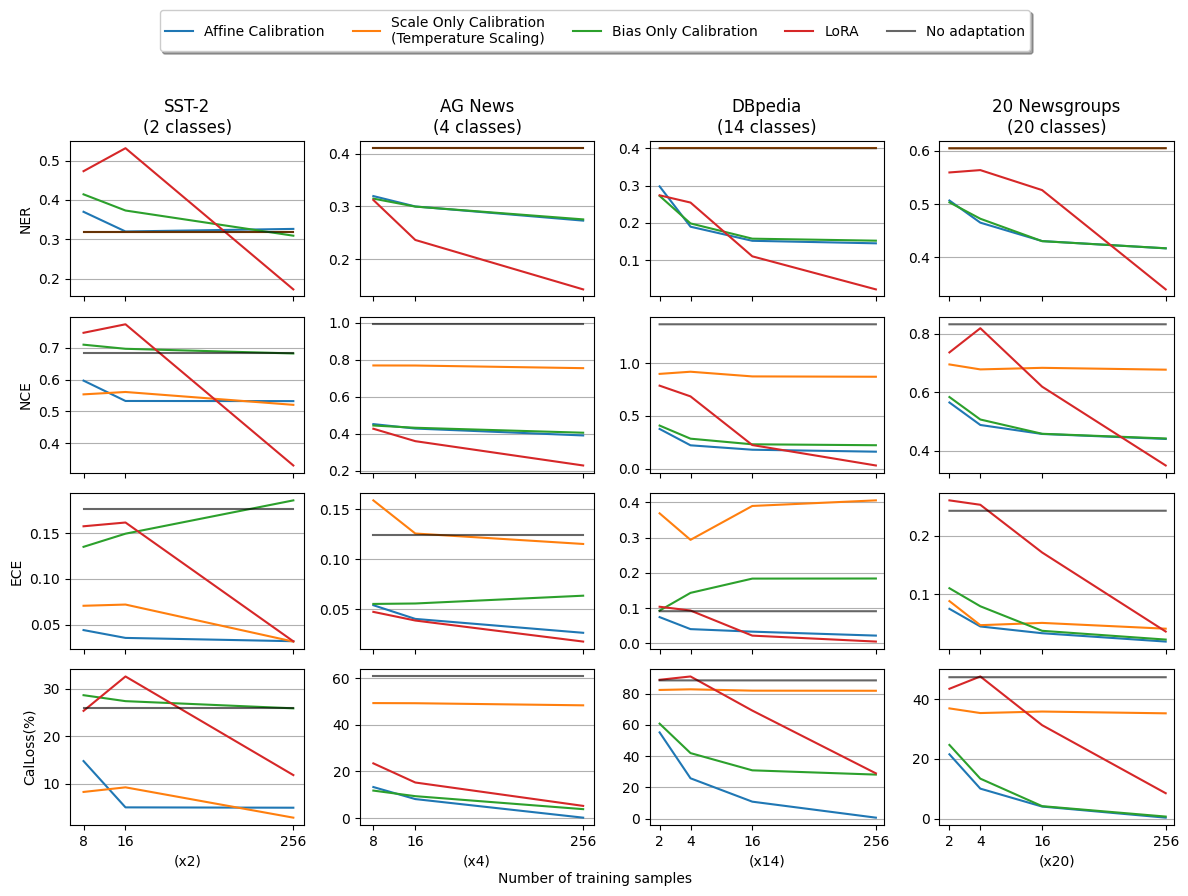

In [6]:
plot_results_for_model(df_results, "lm_tinyllama", metrics[:4], width = 0.5)